# Long-form KaiB — survey across known cyanobacteria

**Question:** How widespread is the long-form KaiB (KaiB-long) among sequenced cyanobacteria?

The canonical short-form KaiB (~100 aa, TIGR02654/PF07689) is the well-characterised circadian clock component. A structurally distinct long-form KaiB (~240 aa) has been described in *Anabaena* PCC 7120 and a small number of other strains. Its phylogenetic distribution is poorly characterised.

**Approach:**
1. Fetch all RefSeq cyanobacteria assembly accessions (~2,500 genomes)
2. Download protein FASTAs for each assembly in batches, cached per-genome
3. Search with `hmmsearch` using the `KaiB_longform_Anabaena7120` profile from `db/kai_hmm/KaiABC_correct.hmm`
4. Collate hits with metadata (organism, assembly level, taxonomy)
5. Visualise distribution across cyanobacterial orders

**Runtime:** ~2–4 hours (NCBI download rate-limited). All steps cached — safe to interrupt and resume.

## Setup

In [23]:
from pathlib import Path
import sys, subprocess, time, json, gzip
from Bio import Entrez, SeqIO
import pandas as pd

# Bootstrap: find project root and load shared utilities
_p = Path.cwd().resolve()
for _parent in [_p] + list(_p.parents):
    if (_parent / "Snakefile").exists():
        sys.path.insert(0, str(_parent / "notebooks"))
        break
from utils import find_project_root, load_config

PROJECT = find_project_root()
cfg     = load_config()

Entrez.email   = cfg.get("entrez_email", "jaepeiso@gmail.com")
Entrez.api_key = cfg.get("ncbi_api_key")   # 10 req/s vs 3 req/s without

# ── Paths ─────────────────────────────────────────────────────────────────────
OUT_DIR  = PROJECT / "results" / "kai_survey"
PROT_DIR = OUT_DIR / "proteins"              # one .faa.gz per assembly
HMM_DB   = PROJECT / "db" / "kai_hmm" / "KaiABC_correct.hmm"
HITS_TSV = OUT_DIR / "longKaiB_hits.tsv"
META_TSV = OUT_DIR / "assembly_metadata.tsv"
FIG_DIR  = PROJECT / "results" / "figures"

for d in [OUT_DIR, PROT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT)
print("HMM DB:      ", HMM_DB)
print("Output dir:  ", OUT_DIR)
print("API key set: ", bool(Entrez.api_key))


Project root: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome
HMM DB:       /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/db/kai_hmm/KaiABC_correct.hmm
Output dir:   /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey
API key set:  True


## Tool check

In [24]:
import shutil

_required = {
    "hmmsearch": "HMMER (conda: hmmer)",
    "hmmfetch":  "HMMER (conda: hmmer)",
}
_missing = {k: v for k, v in _required.items() if not shutil.which(k)}
if _missing:
    raise EnvironmentError(
        "Missing tools:\n" + "\n".join(f"  {k} — install: {v}" for k, v in _missing.items())
    )
print("All tools found.")

# Confirm the longKaiB profile is present in the HMM database
hmm_names = [l.split()[1] for l in HMM_DB.read_text().splitlines() if l.startswith("NAME")]
print(f"Profiles in {HMM_DB.name}: {hmm_names}")
if "KaiB_longform_Anabaena7120" not in hmm_names:
    raise ValueError("KaiB_longform_Anabaena7120 not found in HMM DB — run db/kai_hmm/add_longKaiB.py first")


All tools found.
Profiles in KaiABC_correct.hmm: ['KaiA', 'KaiA_N', 'circ_KaiB', 'circ_KaiC', 'KaiB_longform_Anabaena7120']


## Step 1: Fetch RefSeq cyanobacteria assembly list

Retrieves all current RefSeq cyanobacteria assemblies and caches their accession + metadata to `assembly_metadata.tsv`. Re-running skips the fetch if the file already exists.

In [25]:
# ── 1. Fetch all RefSeq cyanobacteria assembly accessions ────────────────────
# Includes FtpPath_RefSeq — used in Step 2 to download protein FASTAs directly
# from NCBI FTP without needing elink.
# Delete assembly_metadata.tsv to force a refresh.

BATCH = 500

if META_TSV.exists():
    df_meta = pd.read_csv(META_TSV, sep="\t")
    print(f"Loaded cached metadata: {len(df_meta):,} assemblies")
    if "ftp_path" not in df_meta.columns:
        print("WARNING: cached metadata missing ftp_path — delete assembly_metadata.tsv and rerun")
else:
    print("Searching NCBI for RefSeq cyanobacteria assemblies...")
    handle = Entrez.esearch(
        db="assembly",
        term="Cyanobacteria[Organism] AND latest_refseq[filter]",
        retmax=10_000
    )
    search = Entrez.read(handle); handle.close()
    ids = search["IdList"]
    print(f"Found {len(ids):,} assemblies")

    records = []
    for i in range(0, len(ids), BATCH):
        batch = ids[i:i+BATCH]
        handle = Entrez.esummary(db="assembly", id=",".join(batch))
        summaries = Entrez.read(handle)["DocumentSummarySet"]["DocumentSummary"]
        handle.close()
        for s in summaries:
            ftp = s.get("FtpPath_RefSeq", "")
            records.append({
                "assembly_accession": s.get("AssemblyAccession", ""),
                "assembly_name":      s.get("AssemblyName", ""),
                "organism":           s.get("Organism", ""),
                "taxid":              s.get("Taxid", ""),
                "assembly_level":     s.get("AssemblyStatus", ""),
                "refseq_category":    s.get("RefSeq_category", ""),
                "biosample":          s.get("BioSampleAccn", ""),
                "ftp_path":           ftp,
            })
        print(f"  {min(i+BATCH, len(ids))}/{len(ids)} summaries fetched")
        time.sleep(0.12 if Entrez.api_key else 0.35)

    df_meta = pd.DataFrame(records)
    df_meta.to_csv(META_TSV, sep="\t", index=False)
    print(f"Saved → {META_TSV.name}")

no_ftp = (df_meta["ftp_path"] == "") | df_meta["ftp_path"].isna()
print(f"\nAssemblies with FTP path: {(~no_ftp).sum():,} / {len(df_meta):,}")
print(df_meta["assembly_level"].value_counts().to_string())


Loaded cached metadata: 2,536 assemblies

Assemblies with FTP path: 2,536 / 2,536
assembly_level
Contig             1311
Scaffold            777
Complete Genome     407
Chromosome           41


## Step 2: Download protein FASTAs

Downloads `protein.faa.gz` for each assembly directly from the NCBI FTP path stored in the metadata. Each file is saved as `{accession}.faa.gz`. Already-downloaded genomes are skipped — safe to interrupt and resume.

This is the main runtime step (~1–3 hours with API key).

In [26]:
# ── 2. Download protein FASTAs via NCBI FTP ───────────────────────────────────
# FTP path format (from metadata):
#   https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/.../GCF_xxx_ASMyyy/
# Protein FASTA filename:
#   {accession}_{assembly_name}_protein.faa.gz
#
# We use curl (streaming, resumable) rather than urllib to handle large files.

import subprocess

SLEEP   = 0.12 if Entrez.api_key else 0.35
n_done  = n_skip = n_fail = n_noftp = 0

rows = df_meta[df_meta["ftp_path"].notna() & (df_meta["ftp_path"] != "")].itertuples()

for row in rows:
    acc      = row.assembly_accession
    asm_name = row.assembly_name
    ftp_base = row.ftp_path.replace("ftp://", "https://")  # use HTTPS

    out_path = PROT_DIR / f"{acc}.faa.gz"
    if out_path.exists() and out_path.stat().st_size > 100:
        n_skip += 1
        continue

    # Filename convention: {accession}_{assembly_name}_protein.faa.gz
    fname = f"{acc}_{asm_name}_protein.faa.gz"
    url   = f"{ftp_base}/{fname}"

    result = subprocess.run(
        ["curl", "-fsSL", "--retry", "3", "--retry-delay", "2",
         "-o", str(out_path), url],
        capture_output=True
    )
    if result.returncode != 0 or not out_path.exists() or out_path.stat().st_size < 100:
        # Some assemblies genuinely have no protein file (non-coding/RNA only)
        if out_path.exists():
            out_path.unlink()
        n_fail += 1
    else:
        n_done += 1

    total = n_done + n_skip + n_fail
    if total % 100 == 0:
        print(f"  {total}/{len(df_meta)}  downloaded={n_done}  skipped={n_skip}  failed={n_fail}")
    time.sleep(SLEEP)

n_noftp = (df_meta["ftp_path"].isna() | (df_meta["ftp_path"] == "")).sum()
print(f"\nDone.")
print(f"  Downloaded : {n_done:,}")
print(f"  Skipped    : {n_skip:,}  (already cached)")
print(f"  Failed     : {n_fail:,}  (no protein file or download error)")
print(f"  No FTP path: {n_noftp:,}")
print(f"  Protein files on disk: {sum(1 for _ in PROT_DIR.glob('*.faa.gz')):,}")



Done.
  Downloaded : 0
  Skipped    : 2,518  (already cached)
  Failed     : 18  (no protein file or download error)
  No FTP path: 0
  Protein files on disk: 2,518


## Step 3: hmmsearch for KaiB-long

Concatenates all protein FASTAs into a single database and runs `hmmsearch` with only the `KaiB_longform_Anabaena7120` profile. Uses all available CPU cores. Result cached to `longKaiB_hits.tsv`.

In [28]:
# ── 3. Run hmmsearch against all proteins ────────────────────────────────────
# NOTE: if you re-downloaded proteins after a failed run, delete
# all_cyano_proteins.faa and longKaiB_tblout.txt before rerunning this cell.
import shutil

CONCAT_FA  = OUT_DIR / "all_cyano_proteins.faa"
TBLOUT     = OUT_DIR / "longKaiB_tblout.txt"
LONGKAIB_HMM  = OUT_DIR / "KaiB_longform.hmm"   # extracted long-form profile
SHORTKAIB_HMM = OUT_DIR / "KaiB_short.hmm"       # extracted short-form profile
TBLOUT_SHORT  = OUT_DIR / "shortKaiB_tblout.txt"

# Extract long-form and short-form profiles separately
for hmm_out, profile_name in [
    (LONGKAIB_HMM,  'KaiB_longform_Anabaena7120'),
    (SHORTKAIB_HMM, 'circ_KaiB'),
]:
    if not hmm_out.exists():
        result = subprocess.run(
            ['hmmfetch', str(HMM_DB), profile_name],
            capture_output=True, text=True
        )
        hmm_out.write_text(result.stdout)
        print(f'Extracted profile → {hmm_out.name}')

# Concatenate protein FASTAs (streaming, avoids loading all into memory)
if not CONCAT_FA.exists() or CONCAT_FA.stat().st_size < 1000:
    print("Concatenating protein FASTAs...")
    faa_files = sorted(PROT_DIR.glob("*.faa.gz"))
    with open(CONCAT_FA, "w") as out_fh:
        for faa in faa_files:
            # Prefix each header with assembly accession for traceability
            acc = faa.stem  # e.g. GCF_000006745.1
            with gzip.open(faa, "rt") as in_fh:
                for line in in_fh:
                    if line.startswith(">"):
                        out_fh.write(f">{acc}|{line[1:]}")
                    else:
                        out_fh.write(line)
    print(f"Concatenated → {CONCAT_FA.name}  ({CONCAT_FA.stat().st_size/1e9:.2f} GB)")
else:
    print(f"Using existing concat: {CONCAT_FA.name}")

# Run hmmsearch
if not TBLOUT.exists():
    n_cpu = subprocess.run(["sysctl", "-n", "hw.logicalcpu"], capture_output=True, text=True)
    n_cpu = n_cpu.stdout.strip() or "4"
    print(f"Running hmmsearch on {n_cpu} CPUs...")
    subprocess.run(
        ["hmmsearch",
         "--tblout", str(TBLOUT),
         "--noali",         # suppress alignment output (faster)
         "-E", "1e-5",      # report threshold (generous; we filter below)
         "--cpu", n_cpu,
         str(LONGKAIB_HMM), str(CONCAT_FA)],
        check=True
    )
    print(f"Done → {TBLOUT.name}")
else:
    print(f'Using cached tblout: {TBLOUT.name}')

# Short-form hmmsearch — no score threshold needed (circ_KaiB is specific)
if not TBLOUT_SHORT.exists():
    print('Running hmmsearch for short-form KaiB...')
    subprocess.run(
        ['hmmsearch',
         '--tblout', str(TBLOUT_SHORT),
         '--noali', '-E', '1e-5',
         '--cpu', n_cpu,
         str(SHORTKAIB_HMM), str(CONCAT_FA)],
        check=True
    )
    print(f'Done → {TBLOUT_SHORT.name}')
else:
    print(f'Using cached tblout: {TBLOUT_SHORT.name}')


Extracted profile → KaiB_short.hmm
Using existing concat: all_cyano_proteins.faa
Using cached tblout: longKaiB_tblout.txt
Running hmmsearch for short-form KaiB...
# hmmsearch :: search profile(s) against a sequence database
# HMMER 3.4 (Aug 2023); http://hmmer.org/
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# query HMM file:                  /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey/KaiB_short.hmm
# target sequence database:        /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey/all_cyano_proteins.faa
# per-seq hits tabular output:     /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/kai_survey/shortKaiB_tblout.txt
# show alignments in output:       no
# sequenc

## Step 4: Parse hits and join metadata

Filters hmmsearch results to a strong e-value threshold (1e-10), maps each hit back to its source assembly accession, and joins organism + taxonomy metadata.

In [29]:
# ── 4. Parse tblout and join assembly metadata ───────────────────────────────
EVALUE_CUTOFF = 1e-10

# Score threshold: the single-sequence HMM cross-detects short-form KaiB at
# scores 50-155. Genuine long-form hits cluster at score >= 200 (clear bimodal
# gap in the distribution). Apply both e-value AND score cutoffs.
SCORE_CUTOFF  = 200.0   # separates long-form from short-form cross-hits

rows = []
with open(TBLOUT) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        cols = line.split()
        evalue = float(cols[4])
        score  = float(cols[5])
        if evalue > EVALUE_CUTOFF or score < SCORE_CUTOFF:
            continue
        # Header format: {assembly_acc}.faa|{original_protein_header}
        # Strip .faa suffix so accession matches metadata table
        header  = cols[0]
        asm_acc = header.split("|")[0].removesuffix(".faa")
        prot_id = "|".join(header.split("|")[1:])
        rows.append({
            "assembly_accession": asm_acc,
            "protein_id":         prot_id,
            "evalue":             evalue,
            "score":              score,
        })

df_hits = pd.DataFrame(rows) if rows else pd.DataFrame(
    columns=["assembly_accession","protein_id","evalue","score"])

# Join metadata
df_hits = df_hits.merge(df_meta, on="assembly_accession", how="left")

# One row per assembly (keep best hit per genome)
df_best = (df_hits.sort_values("evalue")
           .groupby("assembly_accession", as_index=False)
           .first())

df_best.to_csv(HITS_TSV, sep='\t', index=False)

# ── Parse short-form hits ────────────────────────────────────────────────
short_rows = []
with open(TBLOUT_SHORT) as f:
    for line in f:
        if line.startswith('#') or not line.strip(): continue
        cols = line.split()
        if float(cols[4]) > EVALUE_CUTOFF: continue
        asm_acc = cols[0].split('|')[0].removesuffix('.faa')
        short_rows.append({'assembly_accession': asm_acc, 'short_evalue': float(cols[4])})

df_short = (pd.DataFrame(short_rows)
            .sort_values('short_evalue')
            .groupby('assembly_accession', as_index=False).first())

short_accs = set(df_short['assembly_accession'])
all_accs   = set(df_meta['assembly_accession'])
long_accs  = set(df_best['assembly_accession'])

n_both       = len(long_accs & short_accs)
n_long_only  = len(long_accs - short_accs)
n_short_only = len(short_accs - long_accs)
n_neither    = len(all_accs - long_accs - short_accs)

has_prot     = {p.stem for p in (OUT_DIR / 'proteins').glob('*.faa.gz')}
n_no_prot    = len(all_accs - long_accs - short_accs - has_prot)
n_no_hit     = n_neither - n_no_prot

print(f'Short-form KaiB:   {len(short_accs):,} ({100*len(short_accs)/len(df_meta):.1f}%)')
print(f'Long-form only:    {n_long_only:,}')
print(f'Short-form only:   {n_short_only:,}')
print(f'Both forms:        {n_both:,}')
print(f'No KaiB detected:  {n_no_hit:,}  (protein data present, no hit)')
print(f'No protein data:   {n_no_prot:,}  (download failed or unannotated)')
print()
print('Note: long-form KaiB is always co-present with short-form KaiB (0 long-only strains).')
print('Consistent with long-form KaiB being an accessory regulator, not a core oscillator component.')
print(f"KaiB-long hits (e ≤ {EVALUE_CUTOFF:.0e}, score ≥ {SCORE_CUTOFF:.0f}): {len(df_best):,} assemblies")
print(f"Out of {len(df_meta):,} total RefSeq cyanobacteria")
print(f"Prevalence: {100*len(df_best)/len(df_meta):.1f}%")
print()
print(df_best[["organism","assembly_level","evalue","score"]]
      .sort_values("evalue").to_string(index=False))


Short-form KaiB: 2,481 assemblies (97.8%)
Long-form only:  0
Short-form only: 778
Both forms:      1,703
Neither:         55
KaiB-long hits (e ≤ 1e-10, score ≥ 200): 1,703 assemblies
Out of 2,536 total RefSeq cyanobacteria
Prevalence: 67.2%

                                                                          organism  assembly_level        evalue  score
                                   Nostoc sp. PCC 7120 = FACHB-418 (cyanobacteria) Complete Genome 1.800000e-175  590.7
                                   Trichormus variabilis FACHB-171 (cyanobacteria)          Contig 1.800000e-175  590.7
                                            Anabaena sp. FACHB-709 (cyanobacteria) Complete Genome 1.800000e-175  590.7
                                     Anabaena cylindrica FACHB-170 (cyanobacteria)          Contig 1.800000e-175  590.7
                                            Anabaena sp. FACHB-709 (cyanobacteria)          Contig 1.800000e-175  590.7
                                   Nos

## Step 5: Visualise distribution

Bar chart of KaiB-long hit counts grouped by cyanobacterial order, with assembly-level breakdown (complete / scaffold / contig).

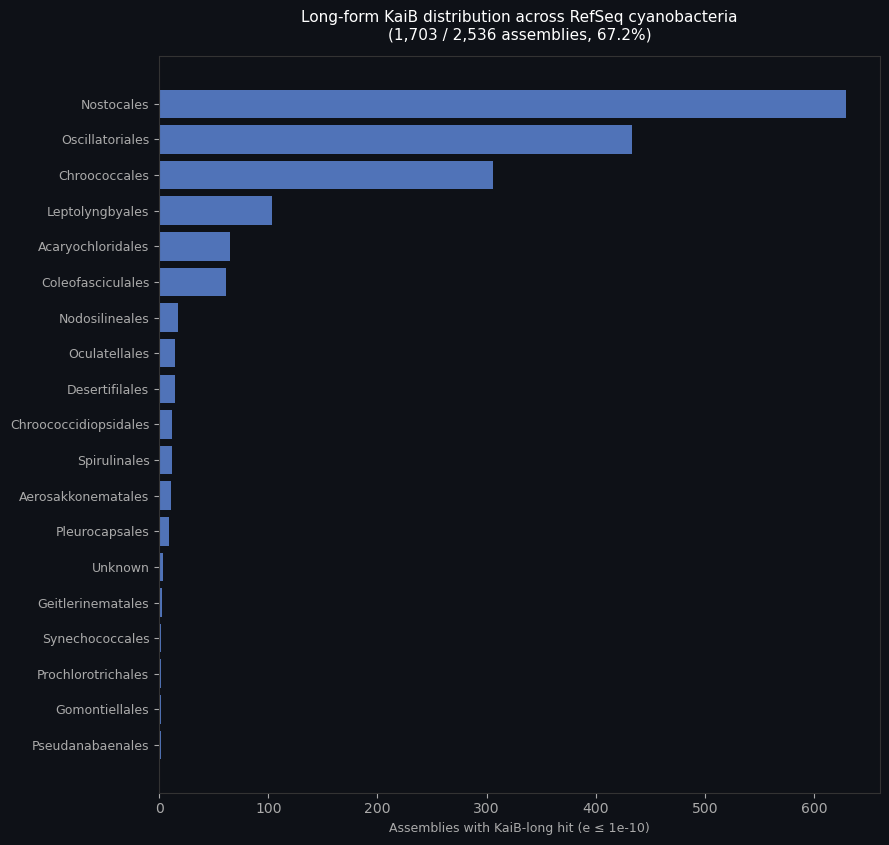

Saved → longKaiB_survey.pdf


In [34]:
# ── 5. Distribution plot across cyanobacterial orders ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

BG = "#0e1117"

# Extract order from organism string where possible
# (RefSeq organism field is typically "Genus species (strain)" — no lineage)
# Use taxid to fetch lineage for hit genomes only (small number of requests)
def get_order(taxid):
    """Fetch lineage for a taxid and return the order-level name."""
    try:
        handle = Entrez.efetch(db="taxonomy", id=str(taxid), retmode="xml")
        records = Entrez.read(handle); handle.close()
        for taxon in records[0].get("LineageEx", []):
            if taxon["Rank"] == "order":
                return taxon["ScientificName"]
    except Exception:
        pass
    return "Unknown"

if "order" not in df_best.columns:
    print("Fetching lineage for hit genomes...")
    orders = {}
    for taxid in df_best["taxid"].unique():
        orders[str(taxid)] = get_order(taxid)
        time.sleep(0.12 if Entrez.api_key else 0.35)
    df_best["order"] = df_best["taxid"].astype(str).map(orders)
    df_best.to_csv(HITS_TSV, sep="\t", index=False)  # update cache

# Count by order
order_counts = df_best.groupby("order").size().sort_values(ascending=True)

LEVEL_COLORS = {
    "Complete Genome": "#20AD62",
    "Chromosome":      "#5BC8AF",
    "Scaffold":        "#5C85D6",
    "Contig":          "#D97B4A",
}

fig, ax = plt.subplots(figsize=(9, max(4, len(order_counts)*0.45)),
                        facecolor=BG)
ax.set_facecolor(BG)

y = range(len(order_counts))
ax.barh(list(y), order_counts.values, color="#5C85D6", alpha=0.85)
ax.set_yticks(list(y))
ax.set_yticklabels(order_counts.index, fontsize=9, color="white")
ax.set_xlabel("Assemblies with KaiB-long hit (e ≤ 1e-10)", color="#aaa", fontsize=9)
ax.tick_params(colors="#aaa")
ax.spines[:].set_color("#333")
ax.set_title(
    f"Long-form KaiB distribution across RefSeq cyanobacteria\n"
    f"({len(df_best):,} / {len(df_meta):,} assemblies, {100*len(df_best)/len(df_meta):.1f}%)",
    color="white", fontsize=11, pad=12
)

plt.tight_layout()
out = FIG_DIR / "longKaiB_survey.pdf"
plt.savefig(out, dpi=200, bbox_inches="tight", facecolor=BG)
plt.savefig(out.with_suffix(".png"), dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Saved → {out.name}")


## Step 6: Short-form vs long-form KaiB — stacked comparison

Stacked bar chart per order showing assemblies with: both forms, long-form only, short-form only, and neither.

Fetching lineage for 687 unresolved taxids...
Done


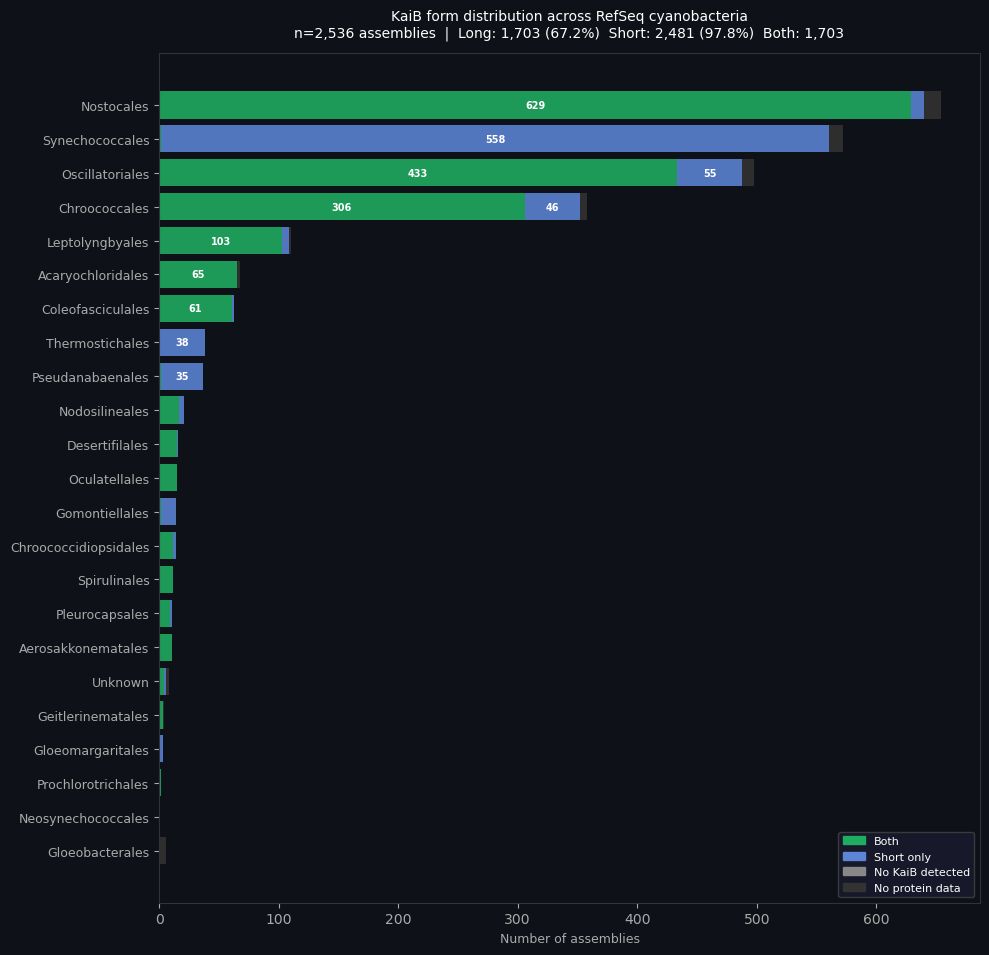

Saved → longKaiB_vs_shortKaiB.pdf


In [35]:
# ── 6. Stacked bar: short / long / both / neither per order ──────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG = '#0e1117'

# Tag every assembly with its KaiB status
# Build taxid → order map from df_best (covers all hit taxids).
# For non-hit assemblies sharing a taxid with a hit, order resolves correctly.
# Remaining unknowns are fetched in a small batch.
df_all = df_meta[['assembly_accession', 'organism', 'assembly_level', 'taxid']].copy()

taxid_order = {}
if 'order' in df_best.columns:
    for _, row in df_best.iterrows():
        if pd.notna(row.get('order')) and row['order'] != 'Unknown':
            taxid_order[str(row['taxid'])] = row['order']

df_all['order'] = df_all['taxid'].astype(str).map(taxid_order)

# Fetch orders for remaining unknown taxids in batches
unknown_taxids = df_all[df_all['order'].isna()]['taxid'].unique().tolist()
if unknown_taxids:
    print(f"Fetching lineage for {len(unknown_taxids)} unresolved taxids...")
    BATCH = 200
    for i in range(0, len(unknown_taxids), BATCH):
        batch = [str(t) for t in unknown_taxids[i:i+BATCH]]
        try:
            handle = Entrez.efetch(db="taxonomy", id=",".join(batch), retmode="xml")
            records = Entrez.read(handle); handle.close()
            for rec in records:
                tid = str(rec['TaxId'])
                order = next(
                    (t['ScientificName'] for t in rec.get('LineageEx', [])
                     if t['Rank'] == 'order'), 'Unknown'
                )
                taxid_order[tid] = order
        except Exception as e:
            print(f"  Batch {i//BATCH} failed: {e}")
        time.sleep(0.12 if Entrez.api_key else 0.35)
    df_all['order'] = df_all['taxid'].astype(str).map(taxid_order).fillna('Unknown')
    print("Done")
df_all['has_long'] = df_all['assembly_accession'].isin(long_accs)
df_all['has_short'] = df_all['assembly_accession'].isin(short_accs)

import os
has_prot = {p.stem for p in (OUT_DIR / 'proteins').glob('*.faa.gz')}

def kaib_status(row):
    if row['has_long'] and row['has_short']:  return 'Both'
    if row['has_long']:                        return 'Long only'
    if row['has_short']:                       return 'Short only'
    if row['assembly_accession'] not in has_prot: return 'No protein data'
    return 'No KaiB detected'

df_all['status'] = df_all.apply(kaib_status, axis=1)

# Count per order × status
pivot = (df_all.groupby(['order', 'status'])
         .size().unstack(fill_value=0)
         .reindex(columns=['Both', 'Long only', 'Short only',
                           'No KaiB detected', 'No protein data'], fill_value=0))

# Sort by total assemblies with any hit (descending)
pivot['_total_hit'] = pivot['Both'] + pivot['Long only'] + pivot['Short only']
pivot = pivot.sort_values('_total_hit').drop(columns='_total_hit')

COLORS = {
    'Both':             '#20AD62',
    'Long only':        '#E8824E',
    'Short only':       '#5C85D6',
    'No KaiB detected': '#888888',
    'No protein data':  '#333333',
}

fig, ax = plt.subplots(figsize=(10, max(5, len(pivot)*0.42)), facecolor=BG)
ax.set_facecolor(BG)

left = np.zeros(len(pivot))
y    = np.arange(len(pivot))
for status, color in COLORS.items():
    vals = pivot[status].values
    ax.barh(y, vals, left=left, color=color, label=status, alpha=0.88)
    # Label bars wider than ~30
    for yi, (v, l) in enumerate(zip(vals, left)):
        if v >= 30:
            ax.text(l + v/2, yi, str(v), ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize=9, color='white')
ax.set_xlabel('Number of assemblies', color='#aaa', fontsize=9)
ax.tick_params(colors='#aaa')
ax.spines[:].set_color('#333')

# Omit 'Long only' from legend since it has 0 entries
handles = [mpatches.Patch(color=COLORS[s], label=s)
           for s in COLORS if s != 'Long only']
ax.legend(handles=handles, fontsize=8, facecolor='#1a1a2e',
          edgecolor='#444', labelcolor='white', loc='lower right')

ax.set_title(
    'KaiB form distribution across RefSeq cyanobacteria\n'
    f'n={len(df_meta):,} assemblies  |  '
    f'Long: {len(long_accs):,} ({100*len(long_accs)/len(df_meta):.1f}%)  '
    f'Short: {len(short_accs):,} ({100*len(short_accs)/len(df_meta):.1f}%)  '
    f'Both: {n_both:,}',
    color='white', fontsize=10, pad=12
)

plt.tight_layout()
out = FIG_DIR / 'longKaiB_vs_shortKaiB.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {out.name}')
